Loading data...
Before SMOTE: Normal = 22180, Fraud = 74
After SMOTE: Normal = 22180, Fraud = 22180

Training XGBoost Model. This might take a minute...
Optimal Threshold for Best F1-Score: 0.9978

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5545
         1.0       1.00      0.79      0.88        19

    accuracy                           1.00      5564
   macro avg       1.00      0.89      0.94      5564
weighted avg       1.00      1.00      1.00      5564



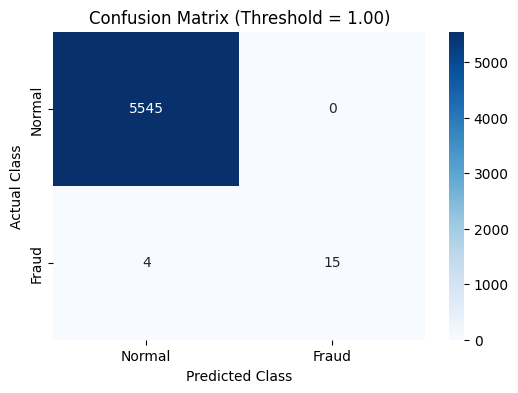

<Figure size 1000x600 with 0 Axes>

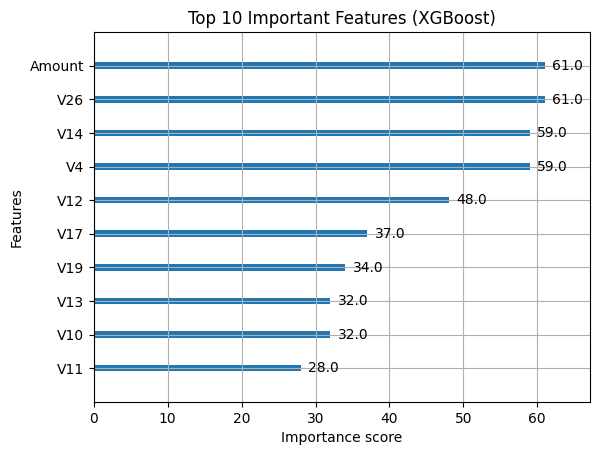

In [1]:
# 1. Install necessary libraries (Colab usually has these, but it's safe to run)
!pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance

# 2. Data Load & Prep
print("Loading data...")
df = pd.read_csv('/content/creditcard.csv')
df=df.dropna()

# 'Time' column modeling ke liye zyada useful nahi hai is single-table approach mein
df = df.drop('Time', axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

# stratify=y ensure karta hai ki train aur test dono mein 0.17% fraud ratio maintain rahe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE (Oversampling) - Sirf Training Data par
print(f"Before SMOTE: Normal = {sum(y_train==0)}, Fraud = {sum(y_train==1)}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: Normal = {sum(y_train_smote==0)}, Fraud = {sum(y_train_smote==1)}\n")

# 4. Train XGBoost Model
print("Training XGBoost Model. This might take a minute...")
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train_smote, y_train_smote)

# 5. Predict Probabilities (Direct class predict karne ki bajaye hum probabilities nikalenge)
y_pred_probs = model.predict_proba(X_test)[:, 1]

# 6. Threshold Tuning (Finding the best threshold for F1-Score)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

# F1 Score ka formula use karke best threshold find karte hain
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold for Best F1-Score: {optimal_threshold:.4f}\n")

# Best threshold apply karke final predictions banate hain
y_pred_optimal = (y_pred_probs >= optimal_threshold).astype(int)

# 7. Evaluation & Confusion Matrix
print("Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_optimal))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_optimal), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# 8. Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=10, importance_type='weight')
plt.title("Top 10 Important Features (XGBoost)")
plt.show()